In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
# loading the dataset
df = pd.read_csv("../datasets/Ru_Nanoparticle/Ru_nanoparticle_dataset.csv")

In [3]:
df

,ID,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,...,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+,Surf_defects_mol,Surf_micros_mol,Surf_facets_mol,Total_E,Formation_E
0,1091,723,50,1,179,61,118,2.410000e-27,5.406953,9.642912,...,0,0,0,0,0,0.000,2754.189,3664.804,-1007.3464,221.3096
1,1092,723,50,2,181,65,116,2.440000e-27,5.287617,9.233302,...,0,0,0,0,0,0.000,309.392,342.541,-1019.5749,222.8091
2,491,423,50,1,191,70,121,2.570000e-27,5.503451,9.733886,...,0,0,0,0,0,0.000,2712.041,3471.204,-1089.7745,221.2495
3,492,423,50,2,192,74,118,2.590000e-27,5.592540,9.485538,...,0,0,0,0,0,0.000,364.583,265.625,-1099.4669,218.4211
4,2291,1323,50,1,247,94,153,3.330000e-27,5.160493,11.990639,...,0,0,0,0,0,12.146,2303.643,1829.959,-1350.9587,344.4493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1909,1173,5,9,17106,14180,2926,2.310000e-25,34.359006,42.839548,...,0,0,0,0,0,0.058,62.259,105.168,-110110.6400,7304.9440
2496,1810,1123,5,10,17144,14207,2937,2.310000e-25,34.950259,40.977497,...,0,0,0,0,0,0.117,59.496,109.076,-110720.1000,6956.3160
2497,1210,823,5,10,17224,14281,2943,2.320000e-25,35.173940,43.210990,...,0,0,0,0,0,0.000,67.058,102.647,-111412.7400,6812.7960
2498,1310,873,5,10,17245,14305,2940,2.320000e-25,35.147969,43.621408,...,0,0,0,0,0,0.116,62.685,106.350,-111171.5600,7198.1200


In [4]:
df = df.drop(['ID'], axis=1)
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [T, tau, time, N_total, N_bulk, N_surface, Volume, R_min, R_max, R_diff, R_avg, R_std, R_skew, R_kurt, S_100, S_111, S_110, S_311, Curve_1-10, Curve_11-20, Curve_21-30, Curve_31-40, Curve_41-50, Curve_51-60, Curve_61-70, Curve_71-80, Curve_81-90, Curve_91-100, Curve_101-110, Curve_111-120, Curve_121-130, Curve_131-140, Curve_141-150, Curve_151-160, Curve_161-170, Curve_171-180, Avg_total, Avg_bulk, Avg_surf, TCN_0, TCN_1, TCN_2, TCN_3, TCN_4, TCN_5, TCN_6, TCN_7, TCN_8, TCN_9, TCN_10, TCN_11, TCN_12, TCN_13, TCN_14, TCN_15, TCN_16, TCN_17, TCN_18, TCN_19, TCN_20, BCN_0, BCN_1, BCN_2, BCN_3, BCN_4, BCN_5, BCN_6, BCN_7, BCN_8, BCN_9, BCN_10, BCN_11, BCN_12, BCN_13, BCN_14, BCN_15, BCN_16, BCN_17, BCN_18, BCN_19, BCN_20, SCN_0, SCN_1, SCN_2, SCN_3, SCN_4, SCN_5, SCN_6, SCN_7, SCN_8, SCN_9, SCN_10, SCN_11, SCN_12, SCN_13, SCN_14, SCN_15, SCN_16, SCN_17, SCN_18, ...]
Index: []

[0 rows x 187 columns]


In [5]:
df2 = df.groupby(['T']).size().reset_index().rename(columns={0:'count'})

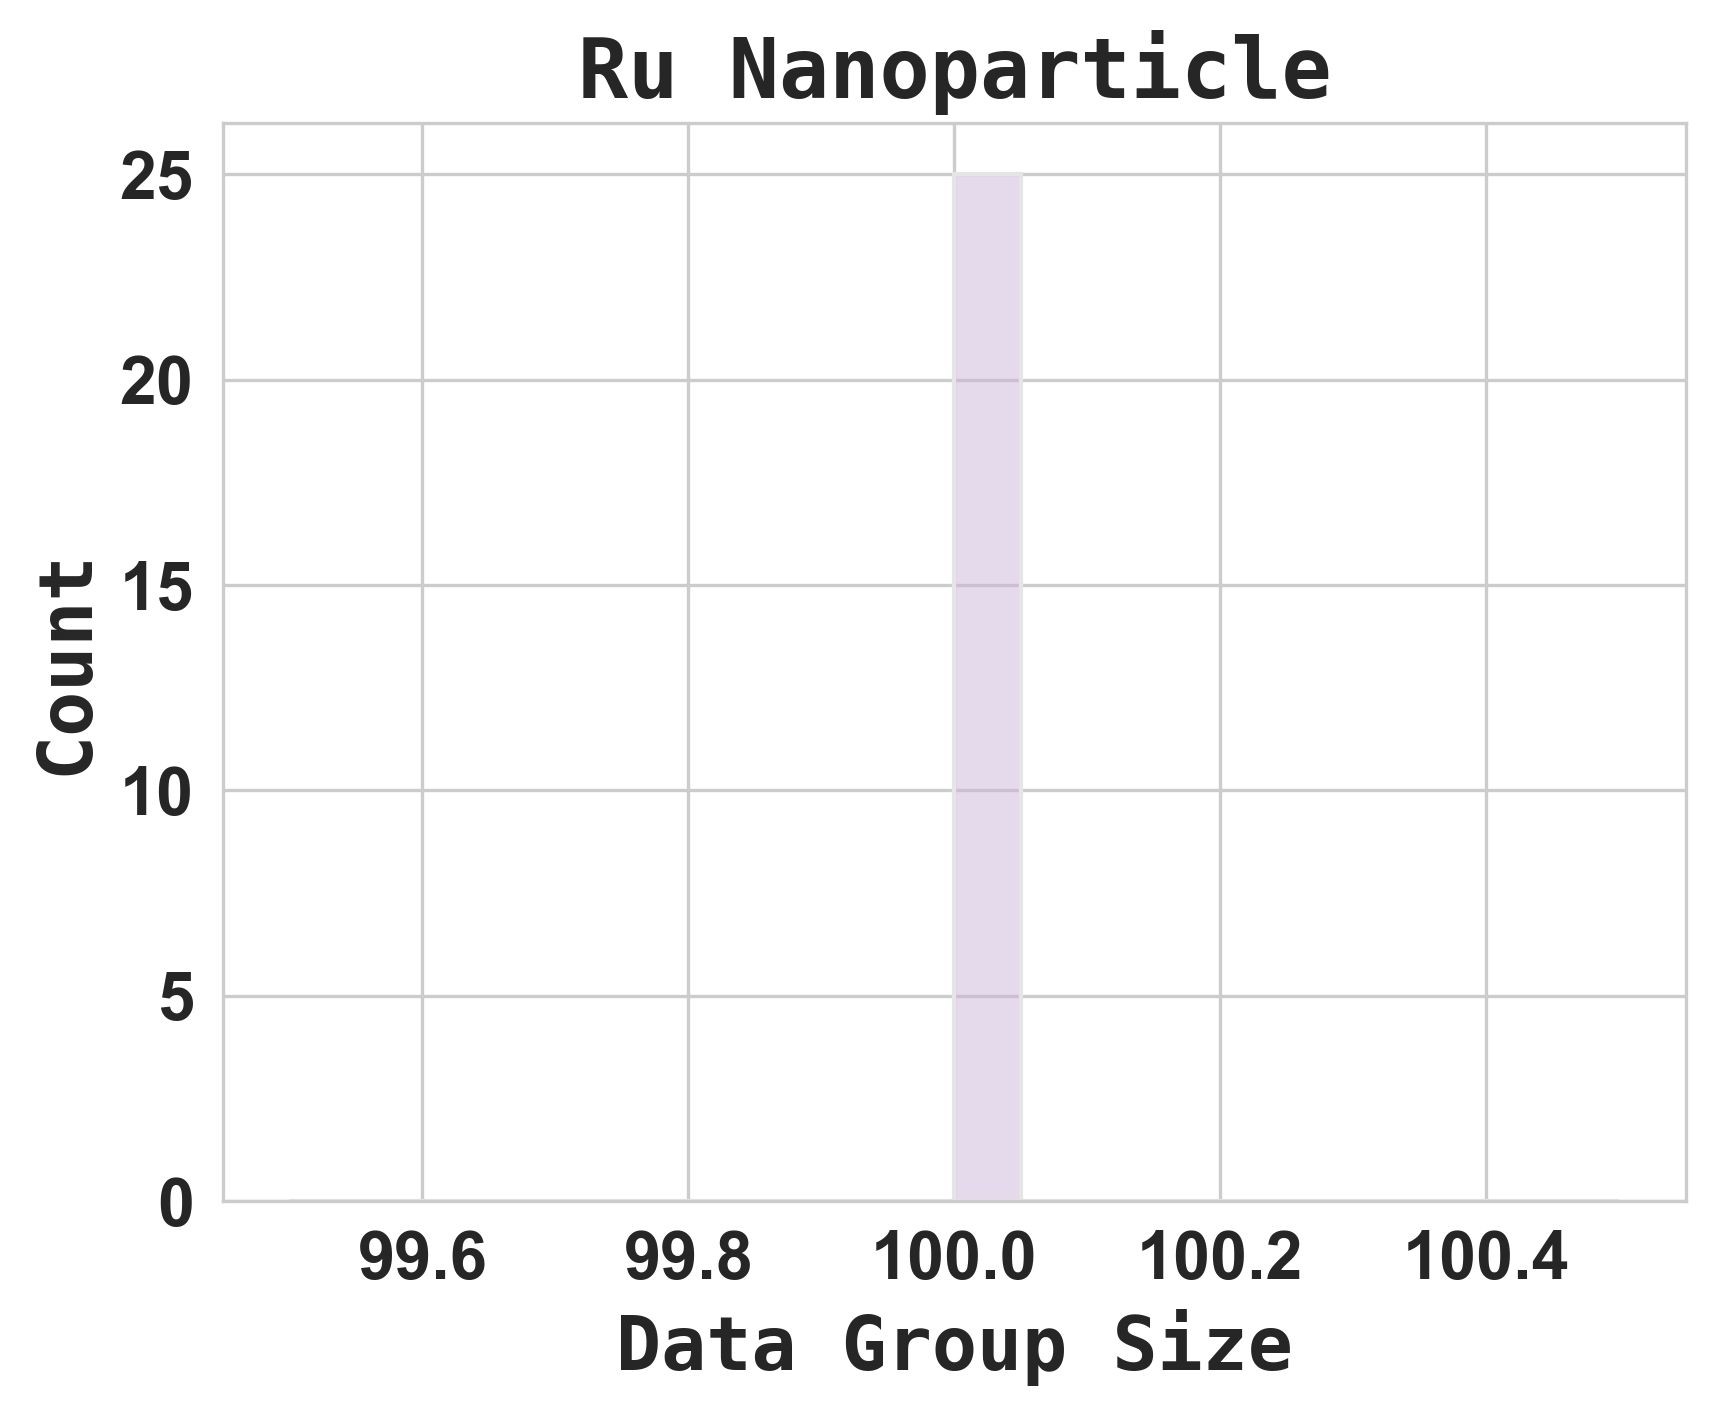

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the plot
font = {'family': 'monospace', 'size': 16, 'weight':'bold'}
plt.rc('font', **font)
plt.rcParams['font.family'] = 'monospace'

sns.set_style("whitegrid")
plt.figure(figsize=(6, 5), dpi=300)

sns.histplot(data=df2, x='count', kde=True, color='#cdb4db', edgecolor='#e5e5e5', bins=20)

plt.title('Ru Nanoparticle', fontsize=20, fontname="monospace",weight='bold')
plt.xlabel('Data Group Size', fontsize=18, fontname="monospace", weight='bold')
plt.ylabel('Count', fontsize=18, fontname="monospace", weight='bold')

# Show the plot
plt.tight_layout()
plt.savefig('Ru_hist.png',
               bbox_inches="tight",
               pad_inches=0.05)
plt.show()

In [7]:
df_subset = df.drop(['Total_E', 'Formation_E', 'Surf_defects_mol', 'Surf_micros_mol', 'Surf_facets_mol'], axis=1)
df_subset

,T,tau,time,N_total,N_bulk,N_surface,Volume,R_min,R_max,R_diff,...,q6q6_S12,q6q6_S13,q6q6_S14,q6q6_S15,q6q6_S16,q6q6_S17,q6q6_S18,q6q6_S19,q6q6_S20,q6q6_S20+
0,723,50,1,179,61,118,2.410000e-27,5.406953,9.642912,4.235959,...,0,0,0,0,0,0,0,0,0,0
1,723,50,2,181,65,116,2.440000e-27,5.287617,9.233302,3.945685,...,0,0,0,0,0,0,0,0,0,0
2,423,50,1,191,70,121,2.570000e-27,5.503451,9.733886,4.230436,...,0,0,0,0,0,0,0,0,0,0
3,423,50,2,192,74,118,2.590000e-27,5.592540,9.485538,3.892998,...,0,0,0,0,0,0,0,0,0,0
4,1323,50,1,247,94,153,3.330000e-27,5.160493,11.990639,6.830146,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1173,5,9,17106,14180,2926,2.310000e-25,34.359006,42.839548,8.480542,...,0,0,0,0,0,0,0,0,0,0
2496,1123,5,10,17144,14207,2937,2.310000e-25,34.950259,40.977497,6.027238,...,0,0,0,0,0,0,0,0,0,0
2497,823,5,10,17224,14281,2943,2.320000e-25,35.173940,43.210990,8.037050,...,1,0,0,0,0,0,0,0,0,0
2498,873,5,10,17245,14305,2940,2.320000e-25,35.147969,43.621408,8.473439,...,0,0,0,0,0,0,0,0,0,0


In [8]:
seed_split = np.load(file="../seed_for_dataSplit.npy")
seed_inital = np.load(file="../seed_for_initialSamples.npy")
seed_model = np.load(file="../seed_for_model.npy")

In [9]:
data = df_subset
labels_true = df[['Formation_E']]

for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(data, labels_true, test_size=0.3, random_state=seed_split[i])
    scaler = preprocessing.StandardScaler()
    X_train[X_train.columns] = scaler.fit_transform(X_train[X_train.columns])
    X_test[X_test.columns] = scaler.transform(X_test[X_test.columns])
    
    X_train.to_csv("../datasets/Ru_Nanoparticle//split_data//X_train" + str(i) +".csv", encoding='utf-8', index=False)
    X_test.to_csv("../datasets/Ru_Nanoparticle//split_data//X_test" + str(i) +".csv", encoding='utf-8', index=False)
    y_train.to_csv("../datasets/Ru_Nanoparticle//split_data//y_train" + str(i) +".csv", encoding='utf-8', index=False)
    y_test.to_csv("../datasets/Ru_Nanoparticle//split_data//y_test" + str(i) +".csv", encoding='utf-8', index=False)